<a href="https://colab.research.google.com/github/lucabarattini/STAT-5703/blob/main/STAT_5703_HW5.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
## STAT-5703 Assignment #5 - Excercice 2:

In [ ]:
# Definining my imports
import numpy as np

In [ ]:
# Parameters
N = 75
p = 0.05
n_chains = 1000
max_iters = 300

# 1. Calculate Theoretical Expectation
theoretical_mean = sum([1 / (1 - (1 - p)**k) for k in range(1, N)])
print(f"Theoretical Expected Time: {theoretical_mean:.4f}")

Theoretical Expected Time: 142.9774


In [ ]:
# 2. Create the Transition Matrix P
P = np.zeros((N, N))
for k in range(1, N):
    p_infect = 1 - (1 - p)**k
    P[k-1, k-1] = 1 - p_infect  # Probability of staying in state k
    P[k-1, k] = p_infect        # Probability of moving to state k+1
P[N-1, N-1] = 1.0               # State N is absorbing

In [ ]:
# 3. Simulate 1000 chains
np.random.seed(5703) # Setting a seed for reproducibility
states = np.arange(1, N + 1)
arrival_times = []

for _ in range(n_chains):
    X = np.zeros(max_iters, dtype=int)
    X[0] = 1 # X_1 = 1 (Time starts at index 0)

    for i in range(1, max_iters):
        current_state = X[i-1]
        # Transition to next state based on probabilities in the transition matrix
        X[i] = np.random.choice(states, p=P[current_state-1])

    # Find the first index i (1-based) where X_i = 75
    indices = np.where(X == 75)[0]
    if len(indices) > 0:
        # +1 because Python is 0-indexed, but the problem states i = 1, ..., 300
        arrival_times.append(indices[0] + 1)

# Calculate the average from the simulation
sim_mean = np.mean(arrival_times)
print(f"Simulated Average Time (1000 chains): {sim_mean:.4f}")

Simulated Average Time (1000 chains): 143.7110


In [ ]:
# 4. Optional: If not close, run for 10,000 chains
if abs(theoretical_mean - sim_mean) > 1.0:
    print("\nDifference is notable. Increasing to 10,000 chains...")
    # (You would wrap the simulation logic in a function and call it here with 10000)

---
## STAT-5703 Assignment #5 - Excercice 3:

In [ ]:
!pip install lifelines

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from lifelines import KaplanMeierFitter
from lifelines.statistics import logrank_test
from lifelines import CoxPHFitter

In [ ]:
# Load the dataset
df = pd.read_csv('AustinCats.csv')
display(df)
# ==========================================
# PART A: Data Coding
# ==========================================
# Convert out_event: 1 if "Adoption", 0 otherwise
df['event'] = np.where(df['out_event'] == 'Adoption', 1, 0)

# Convert color: 1 if "Black", 2 otherwise
df['color_code'] = np.where(df['color'] == 'Black', 1, 2)

# Cap at 365 days
mask = df['days_to_event'] > 365
df.loc[mask, 'event'] = 0
df.loc[mask, 'days_to_event'] = 365

# Report average adoption time for non-censored cats
avg_adoption_time = df[df['event'] == 1]['days_to_event'].mean()
print(f"--- Part A ---")
print(f"Average adoption time for non-censored cats: {avg_adoption_time:.2f} days\n")

,id,days_to_event,date_out,out_event,date_in,in_event,breed,color,intake_age,adopt
0,A730601,1,07/08/2016 09:00:00 AM,Transfer,07/07/2016 12:11:00 PM,Stray,Domestic Shorthair Mix,Blue Tabby,7,0
1,A679549,25,06/16/2014 01:54:00 PM,Transfer,05/22/2014 03:43:00 PM,Stray,Domestic Shorthair Mix,Black/White,1,0
2,A683656,4,07/17/2014 04:57:00 PM,Adoption,07/13/2014 01:20:00 PM,Stray,Snowshoe Mix,Lynx Point,2,1
3,A709749,41,09/22/2015 12:49:00 PM,Transfer,08/12/2015 06:29:00 PM,Stray,Domestic Shorthair Mix,Calico,12,0
4,A733551,9,09/01/2016 12:00:00 AM,Transfer,08/23/2016 02:35:00 PM,Stray,Domestic Shorthair Mix,Brown Tabby/White,1,0
...,...,...,...,...,...,...,...,...,...,...
22351,A772607,10,NaN,Censored,05/21/2018 04:55:00 PM,Stray,Domestic Shorthair Mix,Gray Tabby,24,0
22352,A773005,5,NaN,Censored,05/26/2018 11:32:00 AM,Stray,Domestic Shorthair Mix,Brown Tabby,12,0
22353,A772982,6,NaN,Censored,05/25/2018 06:09:00 PM,Stray,Russian Blue Mix,Blue,120,0
22354,A772687,9,NaN,Censored,05/22/2018 03:37:00 PM,Stray,Tonkinese Mix,Chocolate Point,12,0


--- Part A ---
Average adoption time for non-censored cats: 37.03 days



--- Part B ---
Manual survival probability at >30 days: 0.5644
Package survival probability at >30 days: 0.5644



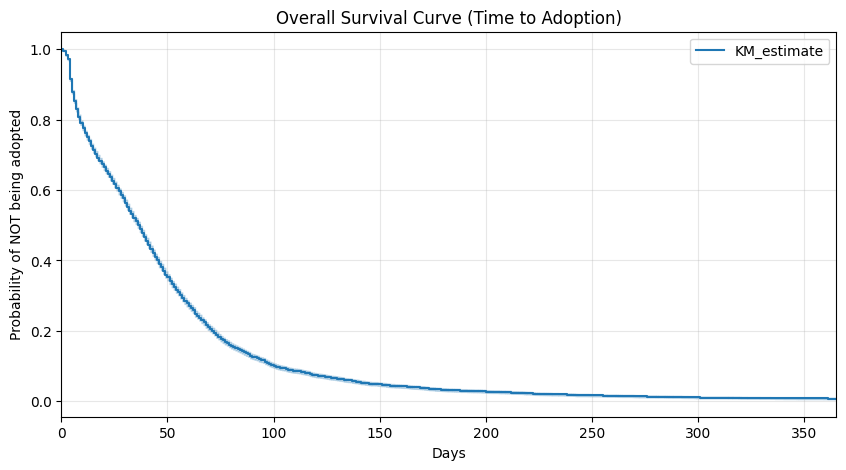

In [ ]:
# ==========================================
# PART B: Manual vs Package Survival at 30 days
# ==========================================
print(f"--- Part B ---")
# 1. Manual Kaplan-Meier Calculation
unique_times = sorted(df['days_to_event'].unique())
n_at_risk = len(df)
manual_survival_prob = 1.0

for t in unique_times:
    if t > 30:
        break
    # d_i: number of adoptions exactly at day t
    d_i = len(df[(df['days_to_event'] == t) & (df['event'] == 1)])
    # c_i: number of censored exactly at day t
    c_i = len(df[(df['days_to_event'] == t) & (df['event'] == 0)])

    if n_at_risk > 0:
        manual_survival_prob *= (1 - d_i / n_at_risk)
    n_at_risk -= (d_i + c_i)

print(f"Manual survival probability at >30 days: {manual_survival_prob:.4f}")

# 2. Package Calculation
kmf = KaplanMeierFitter()
kmf.fit(df['days_to_event'], event_observed=df['event'])
package_surv_30 = kmf.predict(30)
print(f"Package survival probability at >30 days: {package_surv_30:.4f}\n")

# Create a wider figure (Width: 10 inches, Height: 5 inches)
plt.figure(figsize=(10, 5))

kmf.plot_survival_function(title='Overall Survival Curve (Time to Adoption)')
plt.xlim(0, 365)
plt.ylabel('Probability of NOT being adopted')
plt.xlabel('Days')
plt.grid(True, alpha=0.3)

# Save the figure as a high-res, perfectly cropped PNG
plt.savefig('part3_overall_curve.png', dpi=300, bbox_inches='tight')
plt.show()

--- Part C ---



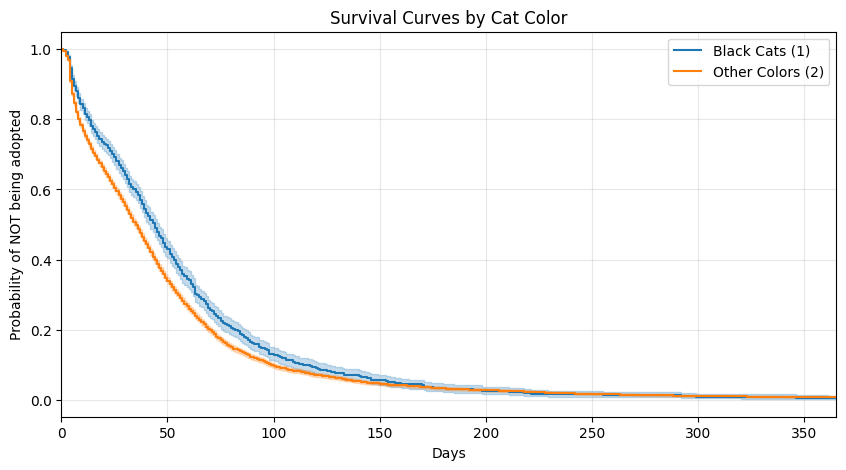


******************************************************************************************************************************************************
Log-rank test p-value: 2.7192e-12



In [ ]:
# ==========================================
# PART C: Survival Curves by Color & Log-Rank Test
# ==========================================
print(f"--- Part C ---")
print()
kmf_black = KaplanMeierFitter()
kmf_other = KaplanMeierFitter()

mask_black = (df['color_code'] == 1)

kmf_black.fit(df[mask_black]['days_to_event'], event_observed=df[mask_black]['event'], label='Black Cats (1)')
kmf_other.fit(df[~mask_black]['days_to_event'], event_observed=df[~mask_black]['event'], label='Other Colors (2)')

# Create a wider figure (Width: 10 inches, Height: 5 inches)
plt.figure(figsize=(10, 5))

ax = kmf_black.plot_survival_function()
kmf_other.plot_survival_function(ax=ax)
plt.title('Survival Curves by Cat Color')
plt.xlim(0, 365)
plt.ylabel('Probability of NOT being adopted')
plt.xlabel('Days')
plt.grid(True, alpha=0.3)

# Save the figure as a high-res, perfectly cropped PNG
plt.savefig('part3_color_curves.png', dpi=300, bbox_inches='tight')
plt.show()

# Log-rank test
results = logrank_test(df[mask_black]['days_to_event'], df[~mask_black]['days_to_event'],
                       event_observed_A=df[mask_black]['event'], event_observed_B=df[~mask_black]['event'])
print()
print('*'*150)
print(f"Log-rank test p-value: {results.p_value:.4e}\n")

In [ ]:
# ==========================================
# PART D: Cox Proportional Hazards Model
# ==========================================
print(f"--- Part D ---")
print()

df_cox = df[['days_to_event', 'event', 'intake_age', 'color_code']].dropna()
cph = CoxPHFitter()
cph.fit(df_cox, duration_col='days_to_event', event_col='event')
cph.print_summary()

--- Part D ---



<lifelines.CoxPHFitter: fitted with 22356 total observations, 11036 right-censored observations>
             duration col = 'days_to_event'
                event col = 'event'
      baseline estimation = breslow
   number of observations = 22356
number of events observed = 11320
   partial log-likelihood = -97305.91
         time fit was run = 2026-04-18 21:22:20 UTC

---
            coef exp(coef)  se(coef)  coef lower 95%  coef upper 95% exp(coef) lower 95% exp(coef) upper 95%
covariate                                                                                                   
intake_age -0.01      0.99      0.00           -0.01           -0.01                0.99                0.99
color_code  0.22      1.25      0.03            0.17            0.28                1.18                1.32

            cmp to      z      p  -log2(p)
covariate                                 
intake_age    0.00 -17.49 <0.005    225.05
color_code    0.00   7.81 <0.005     47.31
---
Concordance = 0.55
Partial AIC = 194615.82
log-likelihood ratio test = 423.63 on 2 df
-log2(p) of ll-ratio test = 305.59

---
## STAT-5703 Assignment #5 - Excercice 4:

In [ ]:
# Doing all the imports:

import numpy as np
import matplotlib.pyplot as plt
from scipy.stats import beta
from scipy.optimize import minimize

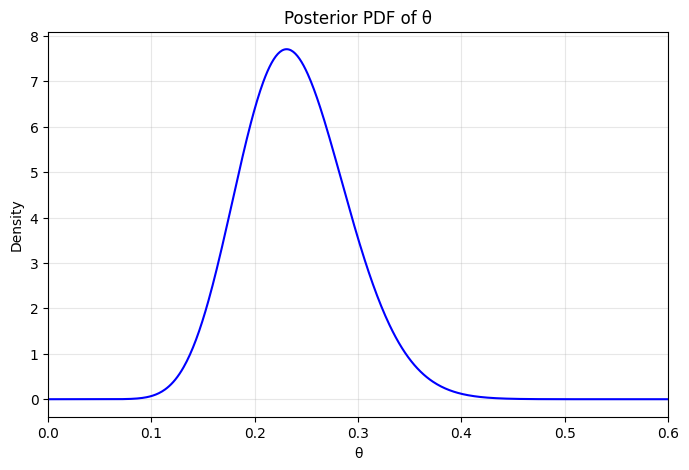

In [ ]:
# Posterior parameters
a_post, b_post = 16, 51

# 1. Plotting the Posterior PDF
x = np.linspace(0, 1, 1000)
y = beta.pdf(x, a_post, b_post)

plt.figure(figsize=(10, 5))
plt.plot(x, y, label='Posterior Beta(16, 51)', color='blue')
plt.title('Posterior PDF of θ')
plt.xlabel('θ')
plt.ylabel('Density')
plt.xlim(0, 0.6) # Cropped for better visibility since density drops to 0 early
plt.grid(alpha=0.3)

Posterior Mean: 0.2388
95% HPDI: [0.1407, 0.3413]



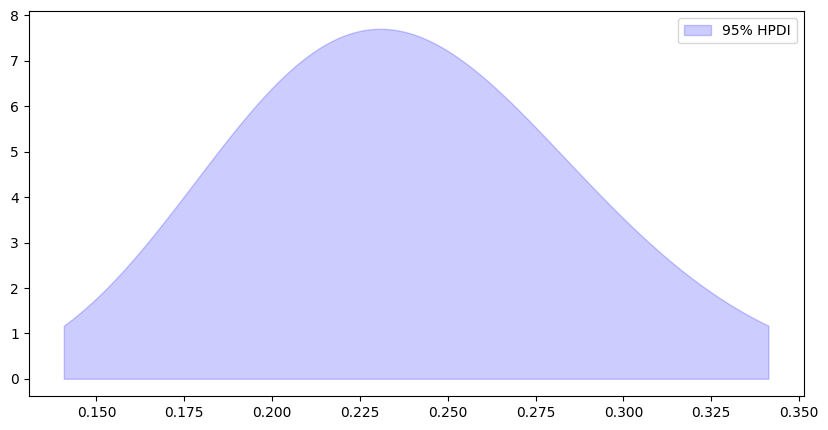

In [ ]:
# 2. Computing the 95% HPDI
# We want to find the interval [lower, upper] that minimizes (upper - lower)
# subject to the constraint that the CDF(upper) - CDF(lower) = 0.95
def objective(lower_bound):
    # Find upper bound that satisfies 95% mass
    upper_bound = beta.ppf(beta.cdf(lower_bound, a_post, b_post) + 0.95, a_post, b_post)
    return upper_bound - lower_bound

# Initial guess: standard symmetric credible interval lower bound
initial_guess = beta.ppf(0.025, a_post, b_post)
res = minimize(objective, initial_guess, bounds=[(0, beta.ppf(0.05, a_post, b_post))])

hpdi_lower = res.x[0]
hpdi_upper = beta.ppf(beta.cdf(hpdi_lower, a_post, b_post) + 0.95, a_post, b_post)

print(f"Posterior Mean: {a_post / (a_post + b_post):.4f}")
print(f"95% HPDI: [{hpdi_lower:.4f}, {hpdi_upper:.4f}]")
print()
# Highlight HPDI on the graph
x_hpdi = np.linspace(hpdi_lower, hpdi_upper, 500)
y_hpdi = beta.pdf(x_hpdi, a_post, b_post)

plt.figure(figsize=(10, 5))
plt.fill_between(x_hpdi, y_hpdi, color='blue', alpha=0.2, label='95% HPDI')
plt.legend()
plt.savefig('posterior_plot.png', dpi=300, bbox_inches='tight')
plt.show()